#  Marathi-English Sentiment Detection — CNN (Multi-Kernel)
**CNN-only model for sentiment classification:**
-  Data augmentation (word dropout)
-  Multi-kernel CNN (bigrams + trigrams + 4-grams)
-  Class-weighted loss (fixes class imbalance)
-  Both Marathi + English fastText embeddings combined
-  Training, Validation **and** Test loss/accuracy graphs
-  Interactive prediction widget

>  **Enable GPU:** Runtime → Change runtime type → T4 GPU

## Step 1: Install & Import

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow openpyxl ipywidgets -q
print('✅ Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.8 MB/s eta 0:00:00
✅ Done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re, pickle, warnings
import ipywidgets as widgets
from IPython.display import display, clear_output
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, BatchNormalization,
    SpatialDropout1D, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Upload & Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Marathi__english_very_less__dataset_for_DM_Proj.xlsx to Marathi__english_very_less__dataset_for_DM_Proj.xlsx


Shape: (1500, 3)
Label distribution:
sentiment
positive    500
neutral     500
negative    500
Name: count, dtype: int64


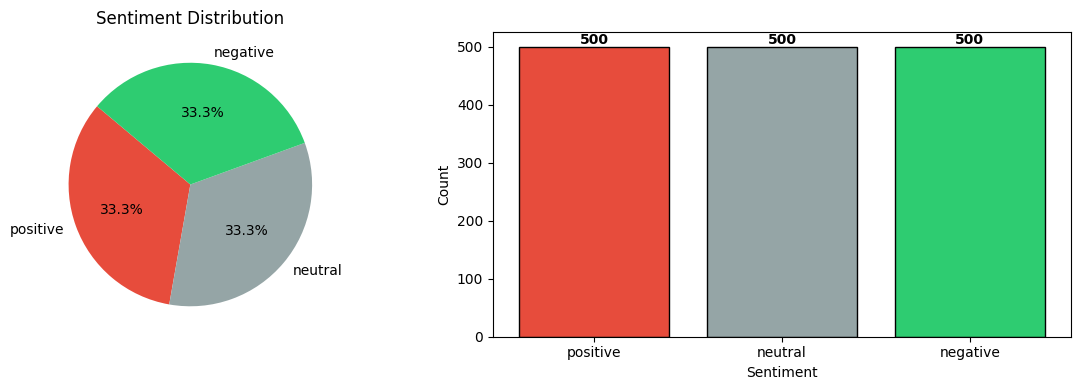

In [ ]:
df = pd.read_excel('Marathi__english_very_less__dataset_for_DM_Proj.xlsx')
df = df.dropna().reset_index(drop=True)

label_map = {-1: 'negative', 0: 'neutral', 1: 'positive'}
df['sentiment'] = df['label'].map(label_map)

print('Shape:', df.shape)
print('Label distribution:')
print(df['sentiment'].value_counts())

counts = df['sentiment'].value_counts()
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[0].set_title('Sentiment Distribution')
bars = axes[1].bar(counts.index, counts.values, color=colors, edgecolor='black')
for bar, c in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(c), ha='center', fontweight='bold')
axes[1].set_xlabel('Sentiment'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.savefig('distribution.png', dpi=150); plt.show()

## Step 3: Text Preprocessing

In [ ]:
def preprocess(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\u0900-\u097Fa-zA-Z\s]', ' ', text)  # keep Devanagari + Latin
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df['clean'] = df['tweet'].apply(preprocess)
df = df[df['clean'].str.strip() != ''].reset_index(drop=True)
print(f'Samples after cleaning: {len(df)}')
df[['tweet','clean','sentiment']].head(4)

Samples after cleaning: 1500


,tweet,clean,sentiment
0,कोरोना काळात आपले पंतप्रधान मा. नरेंद्र मोदी...,कोरोना काळात आपले पंतप्रधान मा नरेंद्र मोदीजी ...,positive
1,पुणे येथे राष्ट्रसेवा दल अभ्यासिका विभाग यां...,पुणे येथे राष्ट्रसेवा दल अभ्यासिका विभाग यांच्...,positive
2,"पुणे येथील ""क्रांती ज्योती"" या कार्यक्रमात ज...",पुणे येथील क्रांती ज्योती या कार्यक्रमात जेष्ठ...,neutral
3,आद्यक्रांतिकारक उमाजीराजे नाईक यांना जयंतीनि...,आद्यक्रांतिकारक उमाजीराजे नाईक यांना जयंतीनिमि...,positive


## Step 4: Data Augmentation
> Doubles training data by randomly dropping 15% of words per sample.
> This forces the model to be robust to missing/unseen tokens — major overfitting fix.

In [ ]:
def augment_text(text, drop_prob=0.15):
    """Randomly drop words to create a slightly different version of the text."""
    words = text.split()
    if len(words) <= 3: return text
    kept = [w for w in words if np.random.rand() > drop_prob]
    return ' '.join(kept) if kept else text

# Only augment training data AFTER splitting to prevent data leakage
print('Augmentation ready (will be applied after split).')

Augmentation ready (will be applied after split).


## Step 5: Download fastText Embeddings (Marathi + English)

In [ ]:
print('Downloading Marathi fastText vectors (~500MB)...')
!wget -q --show-progress https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.mr.300.vec.gz
!gunzip -f cc.mr.300.vec.gz

print('\nDownloading English fastText vectors (~600MB)...')
!wget -q --show-progress https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz
!gunzip -f cc.en.300.vec.gz

print('\n✅ Downloads complete.')

cc.mr.300.vec.gz    100%[===================>] 481.25M  47.3MB/s    in 10s     

cc.en.300.vec.gz    100%[===================>]   1.23G   216MB/s    in 5.7s    

✅ Downloads complete.


In [ ]:
def load_fasttext(path, max_words=60000):
    emb = {}
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        total, dim = map(int, f.readline().split())
        print(f'  Vocab: {total:,} | Dim: {dim}')
        for i, line in enumerate(f):
            if i >= max_words: break
            parts = line.rstrip().split(' ')
            vec   = np.array(parts[1:], dtype=np.float32)
            if len(vec) == dim:
                emb[parts[0]] = vec
    print(f'  Loaded: {len(emb):,}')
    return emb, dim

print('Loading Marathi vectors...')
mr_vecs, EMBED_DIM = load_fasttext('cc.mr.300.vec')

print('Loading English vectors...')
en_vecs, _         = load_fasttext('cc.en.300.vec')

# Merge: Marathi takes priority, English fills gaps
fasttext_vecs = {**en_vecs, **mr_vecs}
print(f'\n✅ Combined vocab: {len(fasttext_vecs):,} | Dim: {EMBED_DIM}')

Loading Marathi vectors...
  Vocab: 845,805 | Dim: 300
  Loaded: 60,000
Loading English vectors...
  Vocab: 2,000,000 | Dim: 300
  Loaded: 60,000

✅ Combined vocab: 112,979 | Dim: 300


## Step 6: Encode Labels & Split

In [ ]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['sentiment'])
NUM_CLASSES = len(le.classes_)
print('Classes:', {i: c for i, c in enumerate(le.classes_)})

X = df['clean'].values
y = df['label_enc'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# ── Apply augmentation to training set only ──────────────────────────────
X_aug = np.array([augment_text(t) for t in X_train])
X_train_all = np.concatenate([X_train, X_aug])
y_train_all = np.concatenate([y_train, y_train])

# Shuffle augmented set
idx = np.random.permutation(len(X_train_all))
X_train_all = X_train_all[idx]
y_train_all = y_train_all[idx]

print(f'After augmentation — Train: {len(X_train_all)}')

y_train_cat = to_categorical(y_train_all, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,       NUM_CLASSES)
y_test_cat  = to_categorical(y_test,      NUM_CLASSES)

Classes: {0: 'negative', 1: 'neutral', 2: 'positive'}
Train: 1050 | Val: 225 | Test: 225
After augmentation — Train: 2100


## Step 7: Tokenise & Build Embedding Matrix

In [ ]:
VOCAB_SIZE = 25000
MAX_LEN    = 100   # Slightly longer window for Marathi morphology

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_all)   # fit on augmented train only
word_index = tokenizer.word_index
print(f'Unique tokens: {len(word_index):,}')

def encode(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts),
                         maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = encode(X_train_all)
X_val_seq   = encode(X_val)
X_test_seq  = encode(X_test)
print(f'Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}')

Unique tokens: 10,894
Train seq: (2100, 100) | Val: (225, 100) | Test: (225, 100)


In [ ]:
num_tokens = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_tokens, EMBED_DIM), dtype=np.float32)

found = 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE: continue
    vec = fasttext_vecs.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f'Embedding matrix: {embedding_matrix.shape}')
print(f'Coverage: {found:,} / {min(len(word_index),VOCAB_SIZE):,}  ({coverage:.1f}%)')

Embedding matrix: (10895, 300)
Coverage: 7,099 / 10,894  (65.2%)


## Step 8: Build CNN (Multi-Kernel) Model

```
Input → Embedding → SpatialDropout
         ├── CNN (k=2) → GlobalMaxPool ┐
         ├── CNN (k=3) → GlobalMaxPool ├── Concat → Dense → Output
         └── CNN (k=4) → GlobalMaxPool ┘
```

In [ ]:
def build_cnn_model(num_tokens, embed_dim, embedding_matrix, max_len, num_classes):
    inputs = Input(shape=(max_len,), name='Input')

    # ── Shared Embedding ──────────────────────────────────────────────
    emb = Embedding(
        input_dim=num_tokens, output_dim=embed_dim,
        weights=[embedding_matrix], input_length=max_len,
        trainable=True, name='Embedding'
    )(inputs)
    emb = SpatialDropout1D(0.2, name='SpatialDrop')(emb)

    # ── Multi-kernel CNN (captures 2-gram, 3-gram, 4-gram patterns) ───
    cnn_pools = []
    for k in [2, 3, 4]:
        c = Conv1D(128, kernel_size=k, activation='relu',
                   padding='same', name=f'CNN_k{k}')(emb)
        c = BatchNormalization(name=f'BN_k{k}')(c)
        c = GlobalMaxPooling1D(name=f'Pool_k{k}')(c)      # (batch, 128)
        cnn_pools.append(c)
    cnn_out = Concatenate(name='CNN_Concat')(cnn_pools)    # (batch, 384)

    # ── Classifier Head ───────────────────────────────────────────────
    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4), name='Dense1')(cnn_out)
    x = BatchNormalization(name='BN_D1')(x)
    x = Dropout(0.4, name='Drop1')(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4), name='Dense2')(x)
    x = Dropout(0.3, name='Drop2')(x)
    outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    return Model(inputs, outputs, name='MultiKernel_CNN')


model = build_cnn_model(num_tokens, EMBED_DIM, embedding_matrix, MAX_LEN, NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
model.summary()

Model: "MultiKernel_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 100, 300)  │  3,268,500 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SpatialDrop         │ (None, 100, 300)  │          0 │ Embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_k2 (Conv1D)     │ (None, 100, 128)  │     76,928 │ SpatialDrop[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_k3 (Conv1D)     │ (None, 100, 128)  │    115,328 │ SpatialDrop[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_k4 (Conv1D)     │ (None, 100, 128)  │    153,728 │ SpatialDrop[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_k2               │ (None, 100, 128)  │        512 │ CNN_k2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_k3               │ (None, 100, 128)  │        512 │ CNN_k3[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_k4               │ (None, 100, 128)  │        512 │ CNN_k4[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool_k2             │ (None, 128)       │          0 │ BN_k2[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool_k3             │ (None, 128)       │          0 │ BN_k3[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool_k4             │ (None, 128)       │          0 │ BN_k4[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNN_Concat          │ (None, 384)       │          0 │ Pool_k2[0][0],    │
│ (Concatenate)       │                   │            │ Pool_k3[0][0],    │
│                     │                   │            │ Pool_k4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense1 (Dense)      │ (None, 256)       │     98,560 │ CNN_Concat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_D1               │ (None, 256)       │      1,024 │ Dense1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Drop1 (Dropout)     │ (None, 256)       │          0 │ BN_D1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense2 (Dense)      │ (None, 128)       │     32,896 │ Drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Drop2 (Dropout)     │ (None, 128)       │          0 │ Dense2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │        387 │ Drop2[0][0]       │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 3,748,887 (14.30 MB)

 Trainable params: 3,747,607 (14.30 MB)

 Non-trainable params: 1,280 (5.00 KB)

## Step 9: Train with Class Weights

In [ ]:
# Class weights on the ORIGINAL (non-augmented) labels
cw_vals = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw_vals))
print('Class weights:', {le.classes_[k]: f'{v:.3f}' for k,v in class_weight_dict.items()})

BATCH_SIZE = 32
EPOCHS     = 100

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

history = model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print('\n✅ Training complete.')

Class weights: {'negative': '1.000', 'neutral': '1.000', 'positive': '1.000'}
Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3746 - loss: 1.5232

66/66 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - accuracy: 0.4100 - loss: 1.4654 - val_accuracy: 0.3467 - val_loss: 1.1355 - learning_rate: 2.0000e-04
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4767 - loss: 1.2494 - val_accuracy: 0.3467 - val_loss: 1.1929 - learning_rate: 2.0000e-04
Epoch 3/100
63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5654 - loss: 1.0921

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5738 - loss: 1.0830 - val_accuracy: 0.4267 - val_loss: 1.1699 - learning_rate: 2.0000e-04
Epoch 4/100
64/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6553 - loss: 0.9041

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6676 - loss: 0.8759 - val_accuracy: 0.4311 - val_loss: 1.2804 - learning_rate: 2.0000e-04
Epoch 5/100
63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7239 - loss: 0.7953

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7381 - loss: 0.7545 - val_accuracy: 0.4667 - val_loss: 1.3124 - learning_rate: 2.0000e-04
Epoch 6/100
63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7681 - loss: 0.6977
Epoch 6: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7781 - loss: 0.6649 - val_accuracy: 0.4578 - val_loss: 1.3226 - learning_rate: 2.0000e-04
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8310 - loss: 0.5843 - val_accuracy: 0.4622 - val_loss: 1.1942 - learning_rate: 1.0000e-04
Epoch 8/100
64/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8752 - loss: 0.5090

...

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9529 - loss: 0.3460 - val_accuracy: 0.6578 - val_loss: 0.9855 - learning_rate: 1.0000e-04
Epoch 17/100
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9661 - loss: 0.3367

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9657 - loss: 0.3331 - val_accuracy: 0.6800 - val_loss: 0.9770 - learning_rate: 1.0000e-04
Epoch 18/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9710 - loss: 0.3278 - val_accuracy: 0.6756 - val_loss: 0.9850 - learning_rate: 1.0000e-04
Epoch 19/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9743 - loss: 0.3228 - val_accuracy: 0.6756 - val_loss: 0.9655 - learning_rate: 1.0000e-04
Epoch 20/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9757 - loss: 0.3204 - val_accuracy: 0.6800 - val_loss: 1.0093 - learning_rate: 1.0000e-04
Epoch 21/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9771 - loss: 0.3119 - val_accuracy: 0.6756 - val_loss: 1.0053 - learning_rate: 1.0000e-04
Epoch 22/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9843 - loss: 0.3069 - val_accuracy: 0.6711 - val_loss: 0.9895 - learning_rate: 1.0000e-04
Epoch 23/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9862 - lo

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9876 - loss: 0.2932 - val_accuracy: 0.6844 - val_loss: 0.9609 - learning_rate: 5.0000e-05
Epoch 27/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9843 - loss: 0.2962 - val_accuracy: 0.6756 - val_loss: 0.9728 - learning_rate: 5.0000e-05
Epoch 28/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9876 - loss: 0.2907 - val_accuracy: 0.6622 - val_loss: 0.9913 - learning_rate: 5.0000e-05
Epoch 29/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9900 - loss: 0.2910 - val_accuracy: 0.6800 - val_loss: 0.9888 - learning_rate: 5.0000e-05
Epoch 30/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9876 - loss: 0.2976 - val_accuracy: 0.6711 - val_loss: 0.9906 - learning_rate: 5.0000e-05
Epoch 31/100
63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9887 - loss: 0.2948
Epoch 31: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9843 - loss: 0.3002 - val_accuracy: 0.6889 - val_loss: 0.9680 - learning_rate: 5.0000e-05
Epoch 32/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9852 - loss: 0.2912 - val_accuracy: 0.6844 - val_loss: 0.9645 - learning_rate: 2.5000e-05
Epoch 33/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9919 - loss: 0.2906 - val_accuracy: 0.6889 - val_loss: 0.9696 - learning_rate: 2.5000e-05
Epoch 34/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9895 - loss: 0.2888 - val_accuracy: 0.6756 - val_loss: 0.9731 - learning_rate: 2.5000e-05
Epoch 35/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9881 - loss: 0.2873 - val_accuracy: 0.6844 - val_loss: 0.9682 - learning_rate: 2.5000e-05
Epoch 36/100
64/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9913 - loss: 0.2912
Epoch 36: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9905 - loss: 0.2

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9938 - loss: 0.2818 - val_accuracy: 0.6933 - val_loss: 0.9625 - learning_rate: 1.2500e-05
Epoch 38/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9919 - loss: 0.2845 - val_accuracy: 0.6800 - val_loss: 0.9659 - learning_rate: 1.2500e-05
Epoch 39/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9914 - loss: 0.2849 - val_accuracy: 0.6756 - val_loss: 0.9586 - learning_rate: 1.2500e-05
Epoch 40/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9957 - loss: 0.2811 - val_accuracy: 0.6800 - val_loss: 0.9602 - learning_rate: 1.2500e-05
Epoch 41/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9881 - loss: 0.2869 - val_accuracy: 0.6756 - val_loss: 0.9689 - learning_rate: 1.2500e-05
Epoch 42/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9895 - loss: 0.2869 - val_accuracy: 0.6711 - val_loss: 0.9621 - learning_rate: 1.2500e-05
Epoch 43/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9900 - los

## Step 10: Training, Validation & Test Loss/Accuracy Graphs
> Test point is shown as a single marker at the final epoch — this is the correct way
> to show test performance (test set is evaluated **once**, not per epoch).

Test Loss     : 0.9815
Test Accuracy : 0.6711  (67.11%)


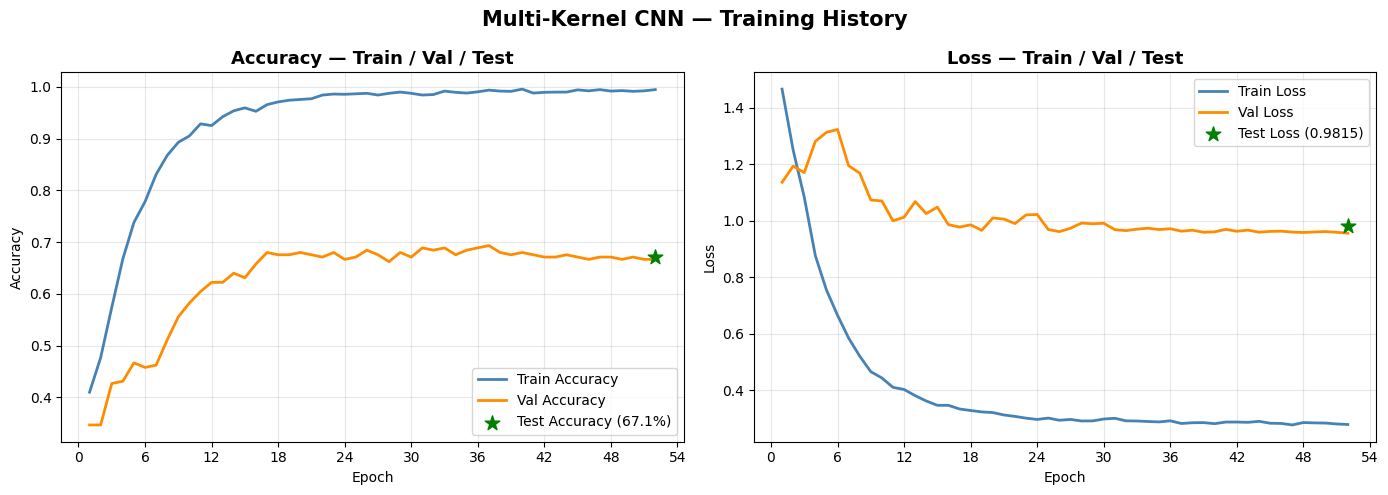

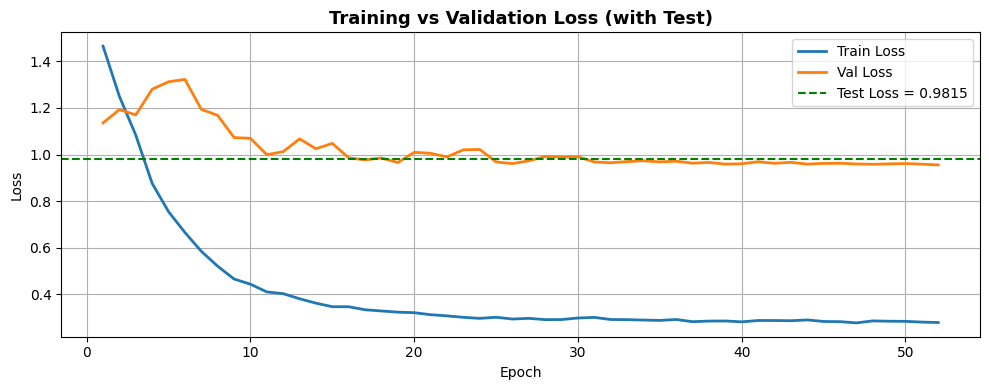

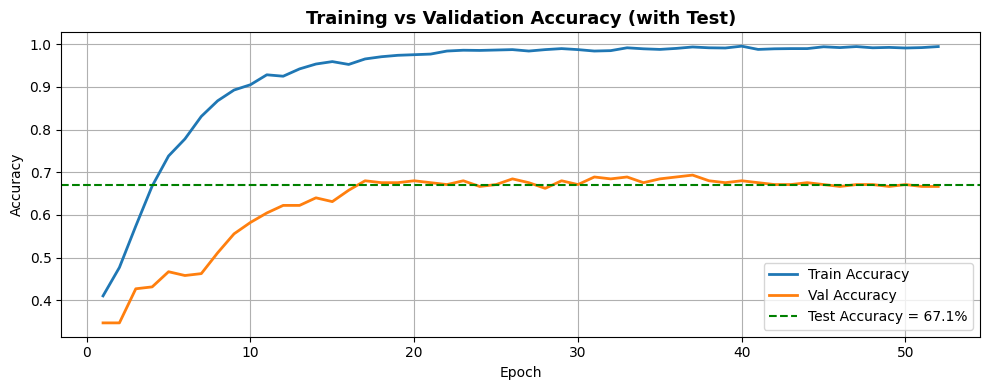

In [ ]:
# Evaluate on test set to get final test loss & accuracy
test_loss, test_acc = model.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

epochs_ran = range(1, len(history.history['loss']) + 1)
final_ep   = len(epochs_ran)

# ── Figure 1: Training vs Validation vs Test ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_ran, history.history['accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'],
             label='Val Accuracy', color='darkorange', linewidth=2)
axes[0].scatter(final_ep, test_acc, color='green', zorder=5, s=120,
                label=f'Test Accuracy ({test_acc*100:.1f}%)', marker='*')
axes[0].set_title('Accuracy — Train / Val / Test', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Loss
axes[1].plot(epochs_ran, history.history['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'],
             label='Val Loss', color='darkorange', linewidth=2)
axes[1].scatter(final_ep, test_loss, color='green', zorder=5, s=120,
                label=f'Test Loss ({test_loss:.4f})', marker='*')
axes[1].set_title('Loss — Train / Val / Test', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.suptitle('Multi-Kernel CNN — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Standalone Training vs Validation Loss (as requested) ───
plt.figure(figsize=(10, 4))
plt.plot(epochs_ran, history.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(epochs_ran, history.history['val_loss'], label='Val Loss',   linewidth=2)
plt.axhline(y=test_loss, color='green', linestyle='--',
            linewidth=1.5, label=f'Test Loss = {test_loss:.4f}')
plt.title('Training vs Validation Loss (with Test)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# ── Figure 3: Standalone Training vs Validation Accuracy ─────────────
plt.figure(figsize=(10, 4))
plt.plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy', linewidth=2)
plt.plot(epochs_ran, history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
plt.axhline(y=test_acc, color='green', linestyle='--',
            linewidth=1.5, label=f'Test Accuracy = {test_acc*100:.1f}%')
plt.title('Training vs Validation Accuracy (with Test)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## Step 11: Classification Report & Confusion Matrix

Classification Report
              precision    recall  f1-score   support

    negative       0.71      0.63      0.67        75
     neutral       0.63      0.79      0.70        75
    positive       0.68      0.60      0.64        75

    accuracy                           0.67       225
   macro avg       0.68      0.67      0.67       225
weighted avg       0.68      0.67      0.67       225



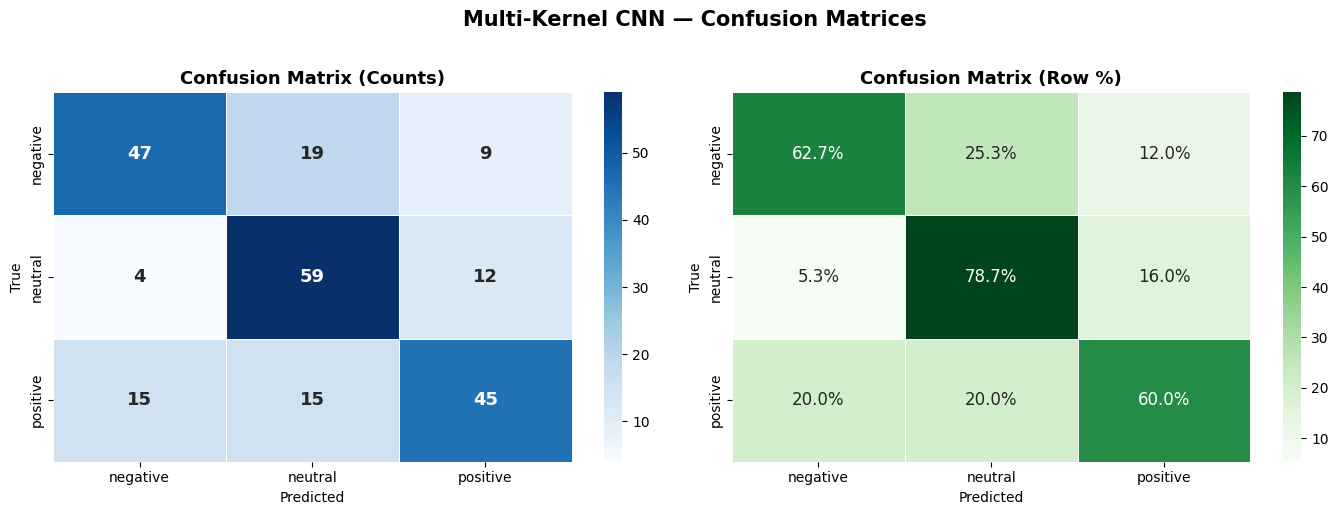

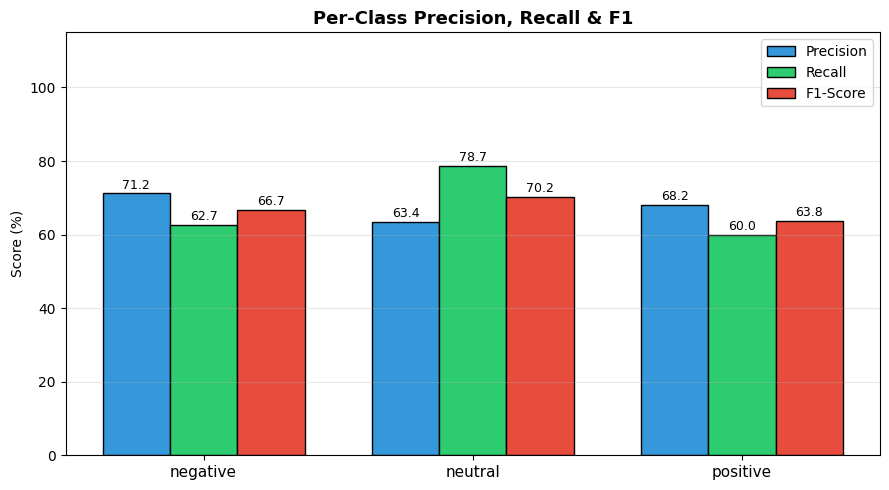

In [ ]:
y_pred = np.argmax(model.predict(X_test_seq, verbose=0), axis=1)

print('Classification Report')
print('=' * 52)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Dual confusion matrix
cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, annot_kws={'size':13,'weight':'bold'}, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, annot_kws={'size':12}, ax=axes[1])
for t in axes[1].texts: t.set_text(t.get_text()+'%')
axes[1].set_title('Confusion Matrix (Row %)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Multi-Kernel CNN — Confusion Matrices',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class F1 bar chart
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
x, width = np.arange(NUM_CLASSES), 0.25
fig, ax = plt.subplots(figsize=(9,5))
b1 = ax.bar(x-width, precision*100, width, label='Precision', color='#3498db', edgecolor='black')
b2 = ax.bar(x,       recall*100,    width, label='Recall',    color='#2ecc71', edgecolor='black')
b3 = ax.bar(x+width, f1*100,        width, label='F1-Score',  color='#e74c3c', edgecolor='black')
for bars in [b1,b2,b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Per-Class Precision, Recall & F1', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(le.classes_, fontsize=11)
ax.set_ylabel('Score (%)'); ax.set_ylim(0,115)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Step 12: Interactive Sentiment Predictor

In [ ]:
def predict_sentiment(text):
    cleaned = preprocess(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs   = model.predict(padded, verbose=0)[0]
    idx     = np.argmax(probs)
    label   = le.classes_[idx]
    return label, probs


def show_widget_prediction(text):
    label, probs = predict_sentiment(text)
    emoji_map = {'negative':'😠','neutral':'😐','positive':'😊'}
    color_map = {'negative':'#e74c3c','neutral':'#3498db','positive':'#2ecc71'}

    fig, ax = plt.subplots(figsize=(6, 2.8))
    colors = [color_map[c] for c in le.classes_]
    bars   = ax.barh(le.classes_, probs*100, color=colors, edgecolor='black', height=0.5)
    for bar, p in zip(bars, probs):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                f'{p*100:.1f}%', va='center', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 120)
    ax.set_xlabel('Confidence (%)')
    ax.set_title(f'Result: {emoji_map[label]}  {label.upper()}',
                 fontsize=14, fontweight='bold', color=color_map[label])
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


txt_box = widgets.Textarea(
    placeholder='Type Marathi / English / Mixed text here...',
    layout=widgets.Layout(width='100%', height='80px')
)
btn = widgets.Button(description='🔍 Predict',
                     button_style='primary',
                     layout=widgets.Layout(width='160px', height='36px'))
out = widgets.Output()

def on_click(b):
    with out:
        clear_output(wait=True)
        t = txt_box.value.strip()
        if t: show_widget_prediction(t)
        else: print('⚠️ Please enter some text.')

btn.on_click(on_click)
display(widgets.VBox([
    widgets.HTML('<h4>✍️ Enter Text Below:</h4>'),
    txt_box, btn, out
]))

## Step 13: Save Model

In [ ]:
model.save('cnn_sentiment.h5')
with open('tokenizer.pkl',     'wb') as f: pickle.dump(tokenizer, f)
with open('label_encoder.pkl', 'wb') as f: pickle.dump(le, f)

print('✅ Saved: cnn_sentiment.h5')
print('✅ Saved: tokenizer.pkl')
print('✅ Saved: label_encoder.pkl')

files.download('cnn_sentiment.h5')
files.download('tokenizer.pkl')
files.download('label_encoder.pkl')

✅ Saved: cnn_sentiment.h5
✅ Saved: tokenizer.pkl
✅ Saved: label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>